In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/shabadpreetsingh/Downloads/IITG/delivery_data.csv')
df['od_start_time'] = pd.to_datetime(df['od_start_time'])

df['hour'] = df['od_start_time'].dt.hour##########################

print("Dataset shape:", df.shape)

Dataset shape: (144867, 25)


In [19]:
print(df['factor'].describe())
print("\n% trips delayed >20%:", round((df['factor'] > 1.2).mean() * 100, 2), "%")
#factor is 1.2 or more
print("OSRM avg prediction (min):", df['osrm_time'].mean().round(1))
#PERCENTILE NIKALNI HAI 95.98.99
print("Actual avg time (min):", df['actual_time'].mean().round(1))
print("OSRM underestimates by:", round((df['actual_time'].mean()/df['osrm_time'].mean()-1)*100, 1), "%")

count    144867.000000
mean          2.120107
std           1.715421
min           0.144000
25%           1.604264
50%           1.857143
75%           2.213483
max          77.387097
Name: factor, dtype: float64

% trips delayed >20%: 94.5 %
OSRM avg prediction (min): 213.9
Actual avg time (min): 416.9
OSRM underestimates by: 94.9 %


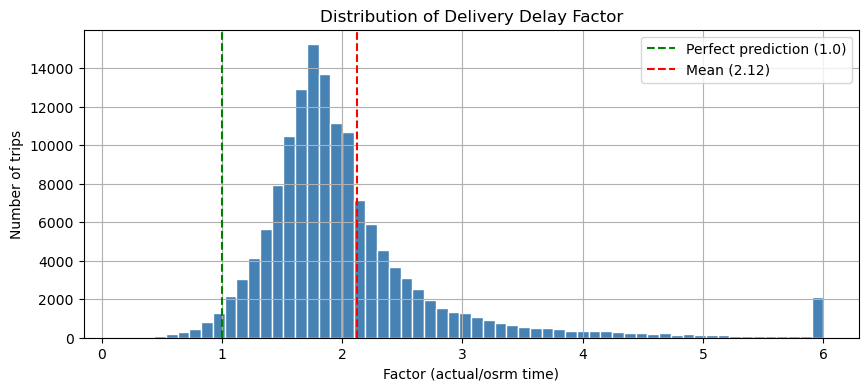

In [29]:
plt.figure(figsize=(10, 4))
df['factor'].clip(upper=6).hist(bins=60, color='steelblue', edgecolor='white')
#Have to explain why clipped at 6
plt.axvline(1.0, color='green', linestyle='--', label='Perfect prediction (1.0)')
plt.axvline(df['factor'].mean(), color='red', linestyle='--', label=f'Mean ({df["factor"].mean():.2f})')
#3 more lines at 95 99 98 percentile
plt.xlabel('Factor (actual/osrm time)')
plt.ylabel('Number of trips')
plt.title('Distribution of Delivery Delay Factor')
plt.legend()
plt.savefig('factor_distribution.png', dpi=150)
plt.show()

In [7]:
df.groupby('route_type')['factor'].agg(['mean','median','count']).round(3)
#percentile nikal lenge

,mean,median,count
route_type,,,
Carting,2.410,1.917,45207
FTL,1.989,1.845,99660


In [37]:
top_delayed = df.groupby('source_name')['factor'].mean().sort_values(ascending=False)
print(top_delayed.to_string())

source_name
Phulpur_Shekhpur_D (Uttar Pradesh)              34.851053
Mariani_Mainroad_D (Assam)                      31.108333
Malvan_BllvMarg_D (Maharashtra)                 23.556107
Surat_Varachha_DC (Gujarat)                     23.502083
Kanpur_Central_D_7 (Uttar Pradesh)              22.183624
Allahabad_Central_D_3 (Uttar Pradesh)           20.189616
Faridabad_Old (Haryana)                         19.083333
RampuraPhul_DC (Punjab)                         15.672365
Helencha_ColnyDPP_D (West Bengal)               15.364719
Ranaghat_ArickDPP_D (West Bengal)               15.179825
Jabalpur (Madhya Pradesh)                       14.772321
Mahasamund_RajpurRD_D (Chhattisgarh)            14.409836
Shirpur_KrantiNgr_D (Maharashtra)               13.850094
Majalgaon_SmbjiCwk_D (Maharashtra)              12.441279
Kanpur_Central_D_5 (Uttar Pradesh)              12.099148
Unnao_VikasRam_D (Uttar Pradesh)                11.189757
HazratJandaha_HajiprRD_D (Bihar)                11.108328
Ja

In [35]:
top_delayed = df.groupby('source_name')['factor'].median().sort_values(ascending=False)
print(top_delayed.to_string())

source_name
Phulpur_Shekhpur_D (Uttar Pradesh)              31.787879
Mariani_Mainroad_D (Assam)                      31.200000
Kanpur_Central_D_7 (Uttar Pradesh)              27.200000
Malvan_BllvMarg_D (Maharashtra)                 26.880918
Shirpur_KrantiNgr_D (Maharashtra)               20.940000
Faridabad_Old (Haryana)                         19.083333
RampuraPhul_DC (Punjab)                         15.672365
Helencha_ColnyDPP_D (West Bengal)               15.351351
Ranaghat_ArickDPP_D (West Bengal)               15.271930
Mahasamund_RajpurRD_D (Chhattisgarh)            14.409836
Jabalpur (Madhya Pradesh)                       14.375000
Simlapal_Central_D_1 (West Bengal)              14.207738
Kanpur_Central_D_5 (Uttar Pradesh)              12.181818
HazratJandaha_HajiprRD_D (Bihar)                11.357466
Pachora_PcrrdDPP_D (Maharashtra)                10.552239
Majalgaon_SmbjiCwk_D (Maharashtra)              10.401964
Benipatti_WardNo1_D (Bihar)                      9.953846
Su

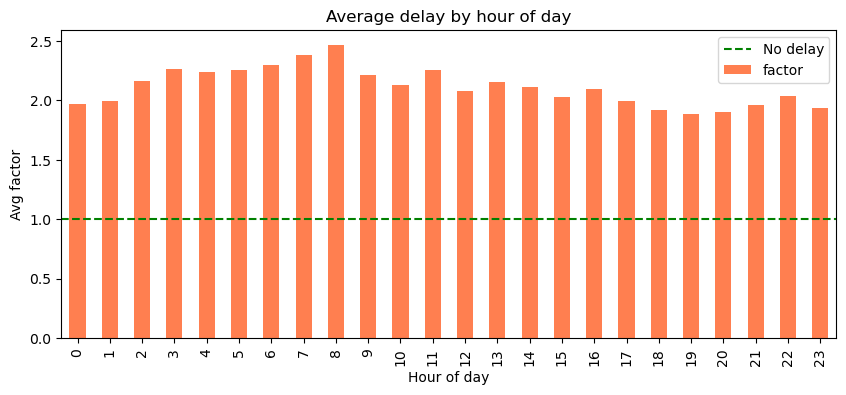

In [11]:
hourly = df.groupby('hour')['factor'].mean()
plt.figure(figsize=(10, 4))
hourly.plot(kind='bar', color='coral')
plt.axhline(1.0, color='green', linestyle='--', label='No delay')
plt.xlabel('Hour of day')
plt.ylabel('Avg factor')
plt.title('Average delay by hour of day')
plt.legend()
plt.savefig('delay_by_hour.png', dpi=150)
plt.show()

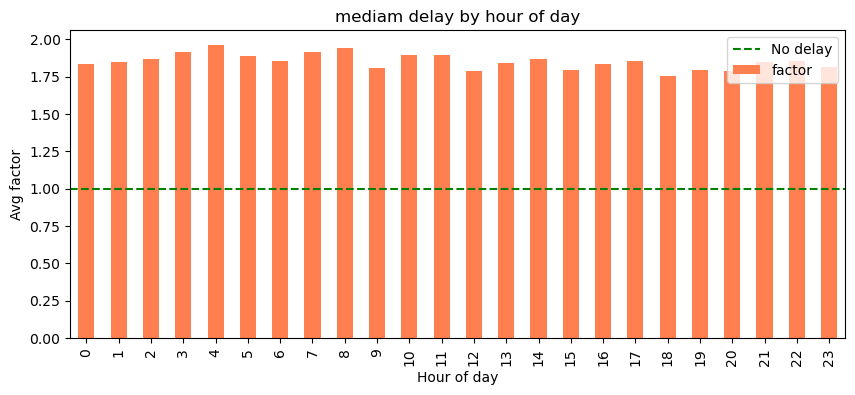

In [39]:
hourly = df.groupby('hour')['factor'].median()
plt.figure(figsize=(10, 4))
hourly.plot(kind='bar', color='coral')
plt.axhline(1.0, color='green', linestyle='--', label='No delay')
plt.xlabel('Hour of day')
plt.ylabel('Avg factor')
plt.title('mediam delay by hour of day')
plt.legend()
plt.show()

In [15]:
# ## Key Observations - Day 2

# 1. OSRM underestimates actual delivery time by ~95% on average
# 2. 94.5% of all trips are delayed by more than 20%
# 3. Average factor is 2.12 — most trips take double the predicted time
# 4. Carting (avg 2.41) is more delayed than FTL (avg 1.99)
# 5. Morning hours (7-9am) have the worst delays
# 6. Some hubs have extreme outlier delays (Phulpur hub: 34x predicted time!)
# 7. The max factor is 77 — there are clear bad-data outliers to clean tomorrow

In [41]:
print(df['factor'].describe())

print("\n95th percentile:", df['factor'].quantile(0.95).round(2))
print("98th percentile:", df['factor'].quantile(0.98).round(2))
print("99th percentile:", df['factor'].quantile(0.99).round(2))

print("\n% trips delayed >20%:",
      round((df['factor'] > 1.2).mean() * 100, 2), "%")

print("OSRM avg prediction (min):",
      df['osrm_time'].mean().round(1))

print("Actual avg time (min):",
      df['actual_time'].mean().round(1))

print("OSRM underestimates by:",
      round(
          (
              df['actual_time'].mean()
              /
              df['osrm_time'].mean()
              - 1
          ) * 100,
          1
      ),
      "%")


#OSRM avg prediction (min): 213.9 yeh outliers hata ke fir dekhenge

count    144867.000000
mean          2.120107
std           1.715421
min           0.144000
25%           1.604264
50%           1.857143
75%           2.213483
max          77.387097
Name: factor, dtype: float64

95th percentile: 3.61
98th percentile: 5.09
99th percentile: 6.96

% trips delayed >20%: 94.5 %
OSRM avg prediction (min): 213.9
Actual avg time (min): 416.9
OSRM underestimates by: 94.9 %


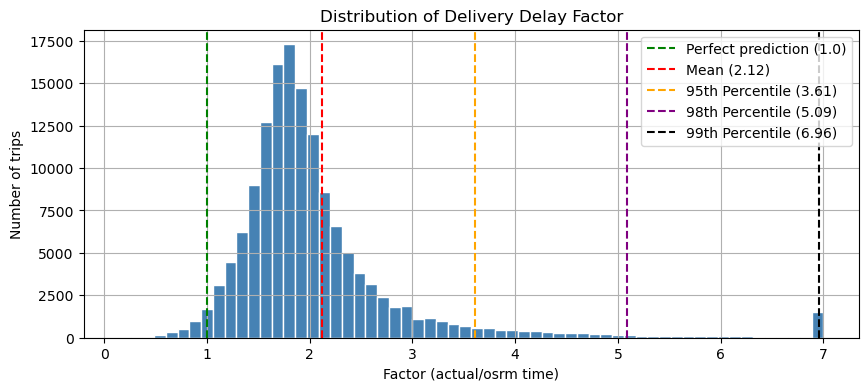

In [45]:
plt.figure(figsize=(10, 4))

df['factor'].clip(upper=7).hist(
    bins=60,
    color='steelblue',
    edgecolor='white'
)

# Reference lines
plt.axvline(
    1.0,
    color='green',
    linestyle='--',
    label='Perfect prediction (1.0)'
)

plt.axvline(
    df['factor'].mean(),
    color='red',
    linestyle='--',
    label=f'Mean ({df["factor"].mean():.2f})'
)

# Percentile lines
plt.axvline(
    df['factor'].quantile(0.95),
    color='orange',
    linestyle='--',
    label=f'95th Percentile ({df["factor"].quantile(0.95):.2f})'
)

plt.axvline(
    df['factor'].quantile(0.98),
    color='purple',
    linestyle='--',
    label=f'98th Percentile ({df["factor"].quantile(0.98):.2f})'
)

plt.axvline(
    df['factor'].quantile(0.99),
    color='black',
    linestyle='--',
    label=f'99th Percentile ({df["factor"].quantile(0.99):.2f})'
)

plt.xlabel('Factor (actual/osrm time)')
plt.ylabel('Number of trips')
plt.title('Distribution of Delivery Delay Factor')

plt.legend()


plt.show()

start_scan_to_end_scan (avg 961 min) vs actual_time (avg 132 min)
The difference (~544 min average) is dwell time — packages sitting idle at a hub waiting to be loaded. This is a hidden delay OSRM never accounts for at all.

So delays come from two places:

Transit delay → captured by segment_factor (road is slow)

Dwell delay → captured by start_scan_to_end_scan -(minus) actual_time (package sitting at hub)

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/Users/shabadpreetsingh/Downloads/IITG/delivery_data.csv')
df['od_start_time'] = pd.to_datetime(df['od_start_time'])
df['od_end_time']   = pd.to_datetime(df['od_end_time'])

df['start_hour']         = df['od_start_time'].dt.hour
df['end_hour']           = df['od_end_time'].dt.hour
df['excess_minutes']     = df['actual_time'] - df['osrm_time']
df['dwell_time']         = df['start_scan_to_end_scan'] - df['actual_time']
df['day_of_week']        = df['od_start_time'].dt.dayofweek  # 0=Mon, 6=Sun
df['dow_name']           = df['od_start_time'].dt.day_name()

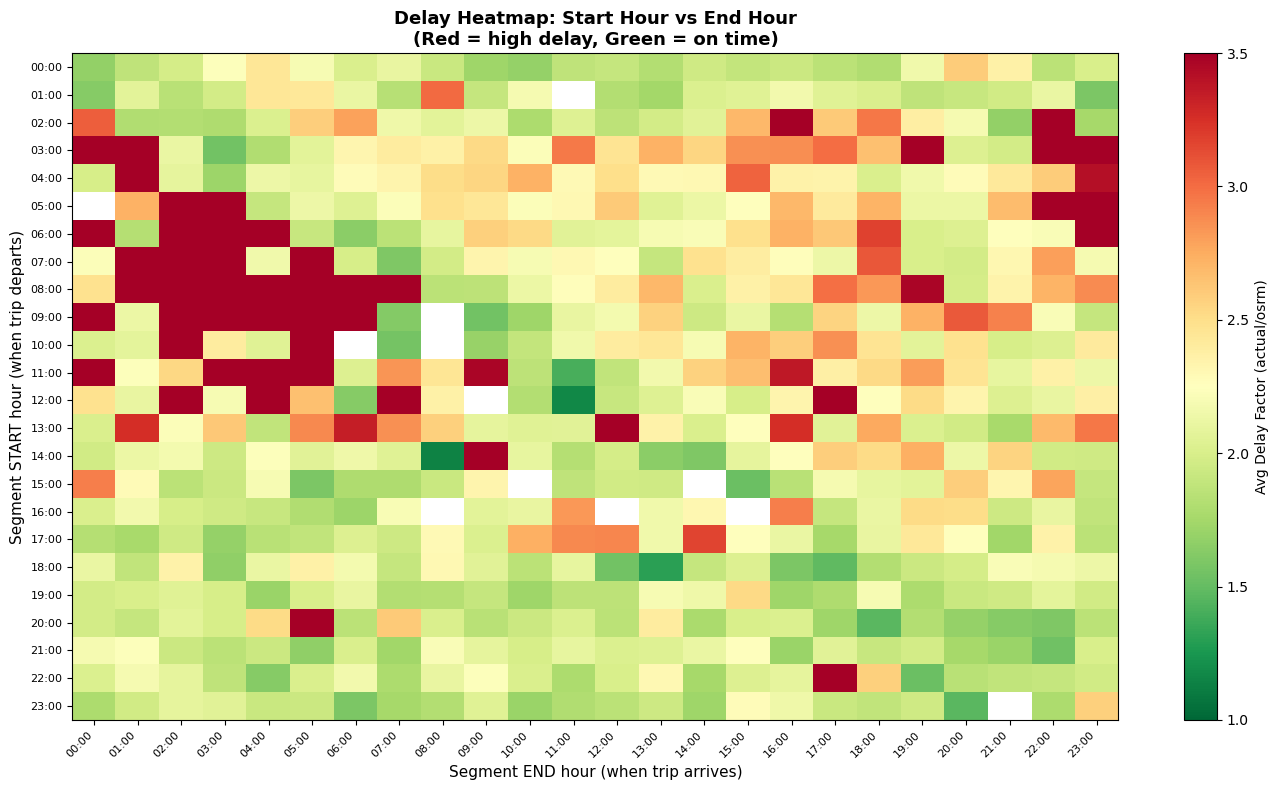

Saved!


In [53]:
# Pivot: rows = start hour, cols = end hour, values = avg segment_factor
pivot = df.pivot_table(
    values='segment_factor',
    index='start_hour',
    columns='end_hour',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto',
               vmin=1.0, vmax=3.5)

ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(24))
ax.set_yticklabels([f'{h:02d}:00' for h in range(24)], fontsize=8)
ax.set_xlabel('Segment END hour (when trip arrives)', fontsize=11)
ax.set_ylabel('Segment START hour (when trip departs)', fontsize=11)
ax.set_title('Delay Heatmap: Start Hour vs End Hour\n(Red = high delay, Green = on time)',
             fontsize=13, fontweight='bold')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Avg Delay Factor (actual/osrm)', fontsize=10)

plt.tight_layout()
plt.savefig('heatmap_start_vs_end_hour.png', dpi=150)
plt.show()
print("Saved!")

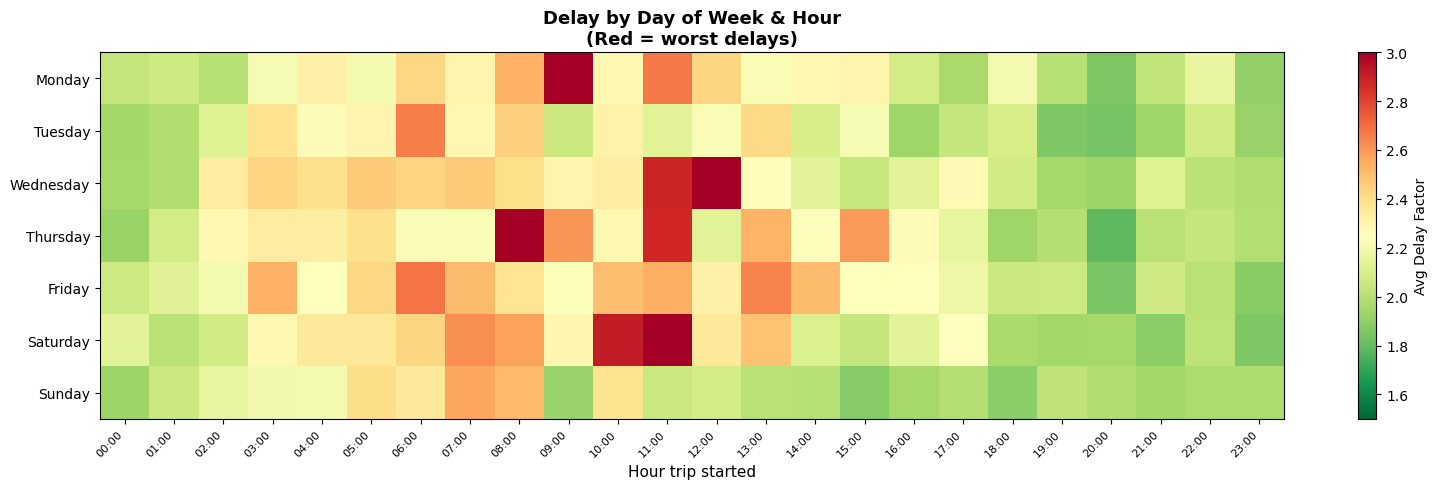

In [55]:
pivot2 = df.pivot_table(
    values='segment_factor',
    index='day_of_week',
    columns='start_hour',
    aggfunc='mean'
)
days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

fig, ax = plt.subplots(figsize=(16, 5))
im2 = ax.imshow(pivot2.values, cmap='RdYlGn_r', aspect='auto', vmin=1.5, vmax=3.0)

ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(7))
ax.set_yticklabels(days, fontsize=10)
ax.set_xlabel('Hour trip started', fontsize=11)
ax.set_title('Delay by Day of Week & Hour\n(Red = worst delays)', fontsize=13, fontweight='bold')

plt.colorbar(im2, ax=ax, label='Avg Delay Factor')
plt.tight_layout()
plt.savefig('heatmap_day_hour.png', dpi=150)
plt.show()

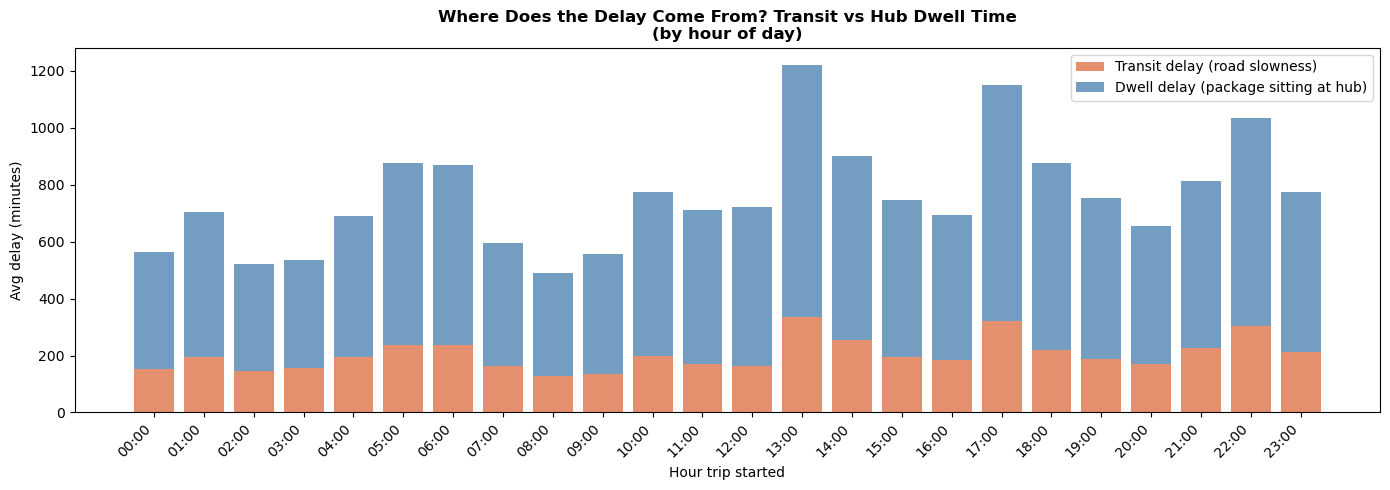

In [60]:
# Two-part bar chart showing WHERE the delay comes from each hour

#yeh shayad theek nahi hai
#dwell time


hourly = df.groupby('start_hour').agg(
    transit_delay=('excess_minutes', 'mean'),
    dwell_delay=('dwell_time', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
x = hourly['start_hour']
ax.bar(x, hourly['transit_delay'], label='Transit delay (road slowness)', color='#E07B54', alpha=0.85)
ax.bar(x, hourly['dwell_delay'], bottom=hourly['transit_delay'],
       label='Dwell delay (package sitting at hub)', color='#5B8DB8', alpha=0.85)

ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right')
ax.set_ylabel('Avg delay (minutes)')
ax.set_xlabel('Hour trip started')
ax.set_title('Where Does the Delay Come From? Transit vs Hub Dwell Time\n(by hour of day)',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('delay_source_by_hour.png', dpi=150)
plt.show()

In [65]:
print(df[[
    'start_scan_to_end_scan',
    'actual_time',
    'dwell_time'
]].describe())

       start_scan_to_end_scan    actual_time     dwell_time
count           144867.000000  144867.000000  144867.000000
mean               961.262986     416.927527     544.335459
std               1037.012769     598.103621     676.891897
min                 20.000000       9.000000       0.000000
25%                161.000000      51.000000      81.000000
50%                449.000000     132.000000     250.000000
75%               1634.000000     513.000000     739.500000
max               7898.000000    4532.000000    5357.000000


In [67]:
# Verify the logic makes sense
print(df[['start_scan_to_end_scan', 'actual_time']].head(10))
print("\nDwell time sample:")
print((df['start_scan_to_end_scan'] - df['actual_time']).head(10))

# Should always be positive (can't drive longer than total time)
negative_dwell = (df['start_scan_to_end_scan'] - df['actual_time']) < 0
print(f"\nRows where dwell is negative (data issues): {negative_dwell.sum()}")

   start_scan_to_end_scan  actual_time
0                      86           14
1                      86           24
2                      86           40
3                      86           62
4                      86           68
5                     109           15
6                     109           44
7                     109           65
8                     109           76
9                     109          102

Dwell time sample:
0    72
1    62
2    46
3    24
4    18
5    94
6    65
7    44
8    33
9     7
dtype: int64

Rows where dwell is negative (data issues): 0
